In [ ]:
import fitz  
import chromadb
from openai import OpenAI

client = OpenAI(
    api_key="your-api-key",
    base_url="https://api.gapgpt.app/v1"
)

EMBED_MODEL = "text-embedding-3-small"
CHAT_MODEL = "gpt-4o-mini"

## Section 1 : Text Extraction

In [2]:
import os

ARTICLES_FOLDER = "articles" 

papers = {}
for fname in sorted(os.listdir(ARTICLES_FOLDER)):
    if fname.lower().endswith(".pdf"):
        paper_name = os.path.splitext(fname)[0]  
        papers[paper_name] = os.path.join(ARTICLES_FOLDER, fname)

In [3]:
import pymupdf4llm

def load_pdf(path):
    md_text = pymupdf4llm.to_markdown(path)
    return md_text

In [4]:
papers_text = {}
for name, path in papers.items():
    papers_text[name] = load_pdf(path)
    print(f"{name}: {len(papers_text[name])} characters extracted")

AlexNet: 42250 characters extracted
EfficientNet: 47572 characters extracted
ResNet: 62455 characters extracted
VGGNet: 56241 characters extracted


## Section 2 : chunking

In [5]:
def expand_squished_table_lines(table_text):
    lines = table_text.split('\n')
    new_lines = []
    for line in lines:
        stripped = line.strip()
        if not stripped.startswith('|'):
            new_lines.append(line)
            continue

        cells = [c.strip() for c in stripped.strip('|').split('|')]

        if all(c == '' or set(c) <= {'-'} for c in cells):
            new_lines.append(line)
            continue

        split_cells = [c.split('<br>') for c in cells]
        n_names = len(split_cells[0])

        if n_names <= 1:
            new_lines.append(line)
            continue

        ok = all(len(c) > 0 and len(c) % n_names == 0 for c in split_cells[1:])
        if not ok:
            new_lines.append(line)
            continue

        for i in range(n_names):
            row_parts = [split_cells[0][i].strip()]
            for c in split_cells[1:]:
                group_size = len(c) // n_names
                group = c[i*group_size:(i+1)*group_size]
                row_parts.append(' | '.join(g.strip() for g in group))
            new_lines.append('| ' + ' | '.join(row_parts) + ' |')

    return '\n'.join(new_lines)

In [6]:
import re

def extract_tables_as_chunks(text, paper_name):
    lines = text.split('\n')
    table_chunks = []
    remaining_lines = []
    i = 0
    n = len(lines)

    while i < n:
        line = lines[i]
        if line.strip().startswith('|'):
            table_lines = []
            while i < n and lines[i].strip().startswith('|'):
                table_lines.append(lines[i])
                i += 1

            j = i
            while j < n and lines[j].strip() == '':
                j += 1
            caption = ""
            if j < n and re.match(r'^\s*Table\s+\d+', lines[j].strip()):
                caption = lines[j].strip()
                i = j + 1

            raw_table_text = "\n".join(table_lines)
            cleaned_table_text = expand_squished_table_lines(raw_table_text)
            table_text = (caption + "\n" if caption else "") + cleaned_table_text
            table_chunks.append(f"[Table from paper: {paper_name}]\n{table_text}")
        else:
            remaining_lines.append(line)
            i += 1

    remaining_text = "\n".join(remaining_lines)
    return table_chunks, remaining_text

In [7]:
def chunk_paper_ultra_safe(text, chunk_size=1200, overlap=200):
    paragraphs = text.split('\n\n')
    chunks = []
    current_chunk = []
    current_word_count = 0
    
    for para in paragraphs:
        para_word_count = len(para.split())
        if not para.strip():
            continue
            
        if current_word_count + para_word_count > chunk_size:
            if current_chunk:
                chunks.append('\n\n'.join(current_chunk))
            current_chunk = current_chunk[-2:] if len(current_chunk) > 2 else current_chunk
            current_word_count = sum(len(p.split()) for p in current_chunk)
            
        current_chunk.append(para)
        current_word_count += para_word_count
        
    if current_chunk:
        chunks.append('\n\n'.join(current_chunk))
        
    return [c.strip() for c in chunks if len(c.strip().split()) > 30]

In [8]:
all_chunks = []
all_metadatas = []
all_ids = []

for name, text in papers_text.items():
    table_chunks, remaining_text = extract_tables_as_chunks(text, name)
    for idx, tc in enumerate(table_chunks):
        all_chunks.append(tc)
        all_metadatas.append({"paper": name, "type": "table"})
        all_ids.append(f"{name}_table_{idx}")

    prose_chunks = chunk_paper_ultra_safe(remaining_text, chunk_size=500, overlap=100)
    for idx, pc in enumerate(prose_chunks):
        all_chunks.append(pc)
        all_metadatas.append({"paper": name, "type": "prose"})
        all_ids.append(f"{name}_prose_{idx}")

print(f"Total number of chunks: {len(all_chunks)}")

Total number of chunks: 115


## Section 3 : Embedding

In [9]:
def get_embedding(text):
    response = client.embeddings.create(
        model=EMBED_MODEL,
        input=text
    )
    return response.data[0].embedding

## Section 4 : Creating Vector Database

In [10]:
db = chromadb.PersistentClient(path="./chroma_store")
collection = db.get_or_create_collection("rag_papers")

In [11]:
def build_index(batch_size=20):
    global collection

    existing_ids = set(collection.get(include=[])["ids"]) if collection.count() > 0 else set()

    if existing_ids == set(all_ids):
        print("Index already exists and matches the current papers, skipping.")
        return

    if existing_ids:
        print("Indexed papers don't match the current article set — rebuilding the collection.")
        db.delete_collection("rag_papers")
        collection = db.get_or_create_collection("rag_papers")

    for i in range(0, len(all_chunks), batch_size):
        batch_chunks = all_chunks[i:i + batch_size]
        batch_ids = all_ids[i:i + batch_size]
        batch_metas = all_metadatas[i:i + batch_size]
        batch_embeds = [get_embedding(c) for c in batch_chunks]

        collection.add(
            ids=batch_ids,
            documents=batch_chunks,
            embeddings=batch_embeds,
            metadatas=batch_metas
        )
        print(f"Indexed: {i + len(batch_chunks)} / {len(all_chunks)}")

    print("Indexing completed.")

In [18]:
build_index()

Indexed: 20 / 115
Indexed: 40 / 115
Indexed: 60 / 115
Indexed: 80 / 115
Indexed: 100 / 115
Indexed: 115 / 115
Indexing completed.


## Section 5 : Rag

In [19]:
PAPER_NAMES = list(papers.keys())

def retrieve(query, top_k_per_paper=5, paper_filter=None):
    query_emb = get_embedding(query)
    papers_to_search = [paper_filter] if paper_filter else PAPER_NAMES

    all_results = []
    for paper_name in papers_to_search:
        results = collection.query(
            query_embeddings=[query_emb],
            n_results=top_k_per_paper,
            where={"paper": paper_name},
            include=["documents", "metadatas", "distances"]
        )
        docs = results['documents'][0]
        metas = results['metadatas'][0]
        distances = results['distances'][0]
        for doc, meta, dist in zip(docs, metas, distances):
            meta = dict(meta)
            meta['score'] = round(1 / (1 + dist), 4)
            all_results.append((doc, meta))

    all_results.sort(key=lambda x: x[1]['score'], reverse=True)
    return all_results

In [20]:
def rag(query, top_k_per_paper=5, paper_filter=None):
    retrieved = retrieve(query, top_k_per_paper=top_k_per_paper, paper_filter=paper_filter)

    context = "\n---\n".join(
        f"[{meta['paper']} | score:{meta.get('score','?')}]: {doc}"
        for doc, meta in retrieved
    )

    strict_prompt = f"""Context:
{context}

Question: {query}

Strict Instructions:
1. Rely ONLY on facts explicitly present in the Context above. Do not use outside knowledge.
2. Tables may have rows merged; carefully reconstruct alignment between names and numbers using their exact order.
3. MANDATORY: If a value is reported as "error rate", you MUST convert it to accuracy yourself
   before any comparison: accuracy (%) = 100 - error_rate (%). Always compare numbers on the
   SAME unit (accuracy vs accuracy), never mix raw error rates with raw accuracies in a comparison.
4. ALWAYS state which paper, which table, and which evaluation protocol or pretraining dataset
   (e.g., single-crop, 10-crop, multi-scale, dense, JFT-300M, ImageNet-21k) each number comes from.
5. CRITICAL: If the question asks about a specific model/paper, but the most relevant number in
   the Context actually comes from a DIFFERENT paper's own re-test of that model, you MUST flag this.
6. CRITICAL FOR COMPARISONS: If the models being compared were evaluated under very different
   conditions (e.g., one model was pretrained on a much larger external dataset like JFT-300M,
   while others were trained only on ImageNet), you MUST explicitly warn that the comparison may
   not be fair, and mention this caveat before declaring a "winner".
7. Only if the answer truly cannot be found, reply with EXACTLY: NOT_FOUND
"""

    first_response = client.chat.completions.create(
        model=CHAT_MODEL,
        messages=[{"role": "user", "content": strict_prompt}]
    )
    answer = first_response.choices[0].message.content.strip()

    if "NOT_FOUND" in answer:
        fallback_response = client.chat.completions.create(
            model=CHAT_MODEL,
            messages=[{"role": "user", "content": query}],
            temperature=0.0
        )
        return (
            "Your query was not found in the articles, "
            "but based on the language model:\n\n"
            + fallback_response.choices[0].message.content
        )

    return answer

## Section 6 : Function Calling

### 6.1 `extract_experimental_results()`

In [21]:
import json

extracted_results_cache = {}

def extract_experimental_results(paper_name=None):

    target_papers = [paper_name] if paper_name else PAPER_NAMES
    results = {}

    for p in target_papers:
        if p in extracted_results_cache:
            results[p] = extracted_results_cache[p]
            continue

        retrieved = retrieve(
            "main experimental results table, primary benchmark evaluation, final performance metrics, top/best accuracy or error rates, tables",
            top_k_per_paper=6,
            paper_filter=p
        )
        context = "\n---\n".join(doc for doc, meta in retrieved)

        extraction_prompt = f"""Context:
{context}

Task:
Identify and extract the evaluation results for the paper '{p}' and it must be evaluation results for th primary dataset .

CRITICAL INSTRUCTION:
There might be multiple datasets mentioned but You MUST choose the PRIMARY benchmark dataset that the paper trained and tested on not those witch used for transfer learning.
Instructions:
1. Extract all major metrics available for the primary dataset of article(e.g.,
 Accuracy (evaluation metric)(report best achieved one)
Precision (evaluation metric)
Recall (evaluation metric)
F1 Score (evaluation metric)
mAP (evaluation metric)
IoU (Efficiency Metrics)
Error Rate (report lowest achieved one)
FLOPs or any metric witch has FLOP in it(Efficiency Metrics)
Parameters of the main model
etc.)  and consider that maybe there is multiple report for a metric tested on different model you have to report the best achieved one.
2. Use standard, clear, and conventional names for the metric keys in Title Case (e.g., "Top-1 Accuracy", "Top-5 Accuracy", "mAP").
3. Convert any error rates to accuracy if necessary (Accuracy = 100 - Error Rate).
4. Include structural metrics like "Number of parameters (Millions)" if present for the main models.

Return STRICT JSON only, no prose, no markdown fences, in this exact schema:
{{
  "paper": "{p}",
  "dataset": "<The name of the primary dataset selected, e.g., ImageNet>",
  "metrics": {{
     "<Standard_Metric_Name_1>": <float or null>,
     "<Standard_Metric_Name_2>": <float or null>
  }},
  "source_note": "<short note on which table/protocol this number came from>"
}}
"""
        resp = client.chat.completions.create(
            model=CHAT_MODEL,
            messages=[{"role": "user", "content": extraction_prompt}],
            temperature=0.0
        )
        raw = resp.choices[0].message.content.strip()
        raw = raw.replace("```json", "").replace("```", "").strip()

        try:
            parsed = json.loads(raw)
            if "metrics" not in parsed or not isinstance(parsed["metrics"], dict):
                parsed["metrics"] = {}
        except json.JSONDecodeError:
            parsed = {
                "paper": p, "dataset": None, "metrics": {},
                "source_note": "parse_failed", "raw": raw
            }

        extracted_results_cache[p] = parsed
        results[p] = parsed

    if paper_name is None and len(results) >= 2:
        all_metric_sets = [set(results[p].get("metrics", {}).keys()) for p in results if results[p].get("metrics")]
        shared_keys = set.intersection(*all_metric_sets) if all_metric_sets else set()

        if shared_keys and len(shared_keys) >= 2:
            filtered_results = {}
            for p in results:
                filtered_results[p] = {
                    "paper": results[p]["paper"],
                    "dataset": results[p]["dataset"],
                    "metrics": {k: results[p]["metrics"].get(k) for k in shared_keys},
                    "source_note": results[p]["source_note"]
                }
            return filtered_results

        print("Warning: Strict metric intersection was empty. Returning all extracted metrics.")
        return results

    return results

In [22]:
extracted_results_cache.clear()
extract_experimental_results()

{'AlexNet': {'paper': 'AlexNet',
  'dataset': 'ILSVRC-2010',
  'metrics': {'Top-1 Accuracy': 62.5,
   'Top-5 Accuracy': 83.0,
   'Number of Parameters (Millions)': 60},
  'source_note': 'Results summarized in Table 1 and Table 2'},
 'EfficientNet': {'paper': 'EfficientNet',
  'dataset': 'ImageNet',
  'metrics': {'Top-1 Accuracy': 84.26,
   'Top-5 Accuracy': 96.97,
   'Number of Parameters (Millions)': 66},
  'source_note': 'Table 2'},
 'ResNet': {'paper': 'ResNet',
  'dataset': 'ImageNet',
  'metrics': {'Top-1 Accuracy': 80.62,
   'Top-5 Accuracy': 95.51,
   'Number of Parameters (Millions)': 60},
  'source_note': 'Best achieved metrics from Table 4 and Table 3'},
 'VGGNet': {'paper': 'VGGNet',
  'dataset': 'ILSVRC',
  'metrics': {'Top-1 Accuracy': 76.3,
   'Top-5 Accuracy': 93.2,
   'Number of Parameters (Millions)': 138},
  'source_note': 'Top-1 and Top-5 Accuracy from the first table, mAP from the last table.'}}

### 6.2 `compare_results()`

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

def compare_results(papers=None, verbose=True):

    target_papers = papers if papers else PAPER_NAMES
    extracted = extract_experimental_results()
    rows = []
    for p in target_papers:
        entry = extracted.get(p, {})
        row = {"paper": p, "dataset": entry.get("dataset")}
        metrics_dict = entry.get("metrics", {})
        for metric_name, value in metrics_dict.items():
            row[metric_name] = value
        rows.append(row)

    df = pd.DataFrame(rows)
    if verbose:
        display(df)

    if verbose:
        potential_metrics = [col for col in df.columns if col not in ["paper", "dataset"]]
        for metric in potential_metrics:
            if pd.api.types.is_numeric_dtype(df[metric]):
                plot_df = df.dropna(subset=[metric])
                if not plot_df.empty:
                    plt.figure(figsize=(6, 4))
                    plt.bar(plot_df["paper"], plot_df[metric], color='skyblue', edgecolor='black')
                    plt.ylabel(metric)
                    plt.title(f"Comparison of {metric} across papers")
                    plt.xticks(rotation=20)
                    plt.grid(axis='y', linestyle='--', alpha=0.7)
                    plt.tight_layout()
                    plt.show()

    return df

,paper,dataset,Top-1 Accuracy,Top-5 Accuracy,Number of Parameters (Millions)
0,AlexNet,ILSVRC-2010,62.50,83.00,60
1,EfficientNet,ImageNet,84.26,96.97,66
2,ResNet,ImageNet,80.62,95.51,60
3,VGGNet,ILSVRC,76.30,93.20,138


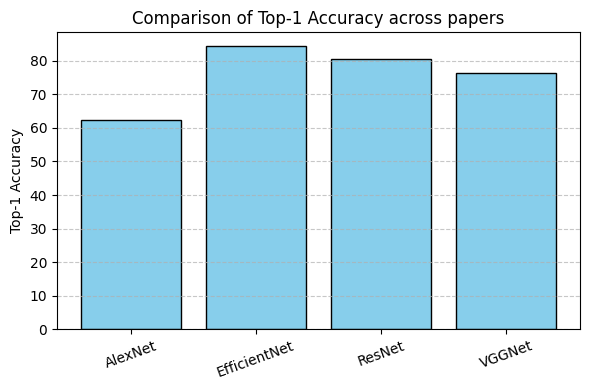

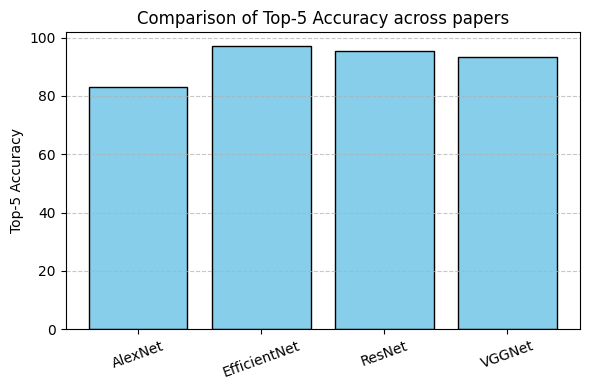

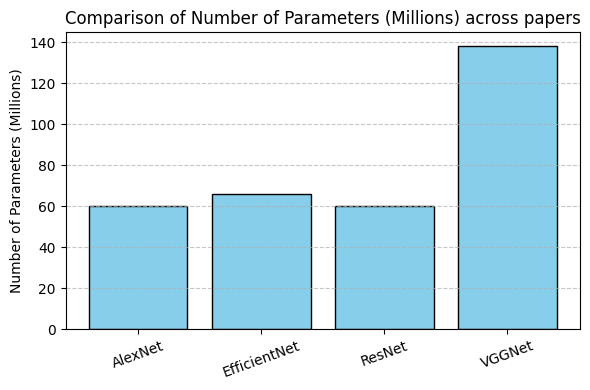

,paper,dataset,Top-1 Accuracy,Top-5 Accuracy,Number of Parameters (Millions)
0,AlexNet,ILSVRC-2010,62.50,83.00,60
1,EfficientNet,ImageNet,84.26,96.97,66
2,ResNet,ImageNet,80.62,95.51,60
3,VGGNet,ILSVRC,76.30,93.20,138


In [24]:
compare_results()

### 6.3 `generate_survey()`

In [25]:
def format_numeric_results_for_prompt(numeric_results):

    lines = []
    for paper, data in numeric_results.items():
        dataset = data.get("dataset", "N/A")
        metrics = data.get("metrics", {})
        metrics_str = ", ".join(
            f"{k}: {v}" for k, v in metrics.items() if v is not None
        )
        lines.append(
            f"- {paper} (dataset: {dataset}): "
            f"{metrics_str if metrics_str else 'no metrics extracted'}"
        )
    return "\n".join(lines)


def generate_survey():
    sections = {}

    # Problem introduction
    intro_ret = retrieve("What problem does this paper address? Introduction and motivation",
                          top_k_per_paper=3)
    intro_context = "\n---\n".join(f"[{m['paper']}]: {d}" for d, m in intro_ret)
    intro_prompt = f"""Context:
{intro_context}

Write a short (4-6 sentence) introduction to the shared research problem addressed by
these papers. Do not mention specific numeric results here."""
    sections["problem_introduction"] = client.chat.completions.create(
        model=CHAT_MODEL, messages=[{"role": "user", "content": intro_prompt}]
    ).choices[0].message.content.strip()

    # Per-paper method summary
    method_summaries = {}
    for p in PAPER_NAMES:
        m_ret = retrieve("What is the proposed method/architecture and its key idea?",
                          top_k_per_paper=4, paper_filter=p)
        m_context = "\n---\n".join(d for d, meta in m_ret)
        m_prompt = f"""Context (paper: {p}):
{m_context}

Summarize in 3-4 sentences the core method/architecture proposed in this paper and
what makes it novel compared to prior work."""
        method_summaries[p] = client.chat.completions.create(
            model=CHAT_MODEL, messages=[{"role": "user", "content": m_prompt}]
        ).choices[0].message.content.strip()
    sections["method_summaries"] = method_summaries

    # Numeric comparison (table + charts) — brought back, no longer commented out
    numeric_df = compare_results(verbose=False)
    sections["numeric_comparison_table"] = numeric_df

    numeric_results = extract_experimental_results()
    numeric_summary_text = format_numeric_results_for_prompt(numeric_results)

    # Qualitative comparison 
    comparison_prompt = f"""Here are short method summaries per paper:
{json.dumps(method_summaries, ensure_ascii=False, indent=2)}

Here are the actual extracted experimental results (numbers) for these papers:
{numeric_summary_text}

Write a 4-6 sentence qualitative comparison of these methods: what architectural or
training differences most likely explain the differences in the numeric performance
listed above. Refer explicitly to the numbers when relevant (e.g. which paper scored
higher/lower on which metric). Do NOT invent any number that is not listed above; if a
paper has no metrics listed, say so instead of guessing."""
    sections["qualitative_comparison"] = client.chat.completions.create(
        model=CHAT_MODEL, messages=[{"role": "user", "content": comparison_prompt}]
    ).choices[0].message.content.strip()

    # Progression of methods
    progression_prompt = f"""Given only these method summaries (do not assume dates you
were not given):
{json.dumps(method_summaries, ensure_ascii=False, indent=2)}

Write a 4-6 sentence narrative describing how the underlying design philosophy for this
problem seems to evolve across these papers, based only on what the summaries say."""
    sections["progression"] = client.chat.completions.create(
        model=CHAT_MODEL, messages=[{"role": "user", "content": progression_prompt}]
    ).choices[0].message.content.strip()

    # Final conclusion
    conclusion_context = f"""Problem introduction:
{sections['problem_introduction']}

Per-paper method summaries:
{json.dumps(method_summaries, ensure_ascii=False, indent=2)}

Extracted numeric results:
{numeric_summary_text}

Qualitative comparison:
{sections['qualitative_comparison']}

Progression of methods:
{sections['progression']}
"""
    conclusion_prompt = f"""Technical analysis so far:
{conclusion_context}

Based strictly on the technical analysis provided above, write a concise 3-4 sentence
final conclusion for this computer vision mini-survey.

CRITICAL CONSTRAINTS:
- Frame the open challenges and future directions exclusively around technical computer
  vision themes.
- Ensure every sentence is directly grounded in the architectural evolution and the
  numeric performance discussed above. Do not introduce any fact, number, or claim that
  is not present in the technical analysis above.
"""
    sections["conclusion"] = client.chat.completions.create(
        model=CHAT_MODEL, messages=[{"role": "user", "content": conclusion_prompt}]
    ).choices[0].message.content.strip()

    try:
        numeric_table_md = numeric_df.to_markdown(index=False)
    except ImportError:
        numeric_table_md = numeric_df.to_string(index=False)

    full_survey = f"""# Mini Survey

Problem Introduction :
{sections['problem_introduction']}

Per-Paper Method Summaries :
""" + "\n".join(f"### {p}\n{s}\n" for p, s in method_summaries.items()) + f"""
Numeric Comparison Table :
{numeric_table_md}

Comparison of Methods :
{sections['qualitative_comparison']}

Progression of Methods :
{sections['progression']}

Conclusion :
{sections['conclusion']}
"""
    sections["full_text"] = full_survey
    print(full_survey)
    return sections

In [26]:
_ = generate_survey()

# Mini Survey

Problem Introduction :
The shared research problem addressed by these papers revolves around improving the performance and efficiency of convolutional neural networks (CNNs) for object recognition tasks, particularly in large-scale settings like the ImageNet dataset. The evolution of CNN architectures has highlighted the challenges associated with network depth, including issues like vanishing gradients and the degradation problem, which hinder optimization as models grow deeper. Researchers have sought to devise innovative strategies, such as residual learning and compound scaling methods, to enhance model accuracy while managing computational complexity. This body of work underscores the importance of both architecture design and training techniques in achieving state-of-the-art results in image classification tasks within the field of computer vision.

Per-Paper Method Summaries :
### AlexNet
The paper presents AlexNet, a deep convolutional neural network architecture

### 6.4 `find_research_gap()`

In [27]:
research_gap_cache = {}

def find_research_gap(paper_name=None):

    target_papers = [paper_name] if paper_name else PAPER_NAMES
    results = {}

    for p in target_papers:
        if p in research_gap_cache:
            results[p] = research_gap_cache[p]
            continue

        retrieved = retrieve(
            "conclusion, limitations, future work, open problems, drawbacks, "
            "what remains unsolved or not addressed",
            top_k_per_paper=6,
            paper_filter=p
        )
        context = "\n---\n".join(doc for doc, meta in retrieved)

        gap_prompt = f"""Context:
{context}

Task:
Based ONLY on the context above (which should mostly come from the conclusion / future work
sections of the paper '{p}'), extract the following:

1. "limitations": explicit limitations or weaknesses the authors themselves acknowledge about their method.
2. "unsolved_problems": problems or questions the paper explicitly states remain open / unsolved / not addressed.
3. "future_work": concrete suggestions or directions the authors propose for future research.

Instructions:
- Use ONLY what is explicitly stated or strongly implied in the context. Do NOT invent anything not mentioned.
- Each item must be a short, self-contained sentence (not a whole paragraph).
- If nothing relevant is found for a category, return an empty list for it — do NOT make something up.
- Return STRICT JSON only, no prose, no markdown fences, in this exact schema:

{{
  "paper": "{p}",
  "limitations": ["<short sentence>", ...],
  "unsolved_problems": ["<short sentence>", ...],
  "future_work": ["<short sentence>", ...]
}}
"""
        resp = client.chat.completions.create(
            model=CHAT_MODEL,
            messages=[{"role": "user", "content": gap_prompt}],
            temperature=0.0
        )
        raw = resp.choices[0].message.content.strip()
        raw = raw.replace("```json", "").replace("```", "").strip()

        try:
            parsed = json.loads(raw)
            for key in ["limitations", "unsolved_problems", "future_work"]:
                if key not in parsed or not isinstance(parsed[key], list):
                    parsed[key] = []
        except json.JSONDecodeError:
            parsed = {
                "paper": p,
                "limitations": [],
                "unsolved_problems": [],
                "future_work": [],
                "parse_failed": True,
                "raw": raw
            }

        research_gap_cache[p] = parsed
        results[p] = parsed

    return results

In [28]:
def display_research_gaps(gaps=None):

    gaps = gaps if gaps is not None else find_research_gap()
    rows = []
    for p, data in gaps.items():
        rows.append({
            "paper": p,
            "limitations": "; ".join(data.get("limitations", [])) or "-",
            "unsolved_problems": "; ".join(data.get("unsolved_problems", [])) or "-",
            "future_work": "; ".join(data.get("future_work", [])) or "-"
        })
    df = pd.DataFrame(rows)
    display(df)
    return df

In [29]:
research_gap_cache.clear()
gaps = find_research_gap()
display_research_gaps(gaps)

,paper,limitations,unsolved_problems,future_work
0,AlexNet,The network’s performance degrades if a single...,We still have many orders of magnitude to go i...,We would like to use very large and deep convo...
1,EfficientNet,-,It remains an open question of how to effectiv...,-
2,ResNet,The testing result of the 1202-layer network i...,The hypothesis regarding the optimization diff...,Combining stronger regularization methods may ...
3,VGGNet,-,-,Better localisation performance can be achieve...


,paper,limitations,unsolved_problems,future_work
0,AlexNet,The network’s performance degrades if a single...,We still have many orders of magnitude to go i...,We would like to use very large and deep convo...
1,EfficientNet,-,It remains an open question of how to effectiv...,-
2,ResNet,The testing result of the 1202-layer network i...,The hypothesis regarding the optimization diff...,Combining stronger regularization methods may ...
3,VGGNet,-,-,Better localisation performance can be achieve...


### 6.5 `compare_limitations()`

In [30]:
def compare_limitations(papers=None):

    target_papers = papers if papers else PAPER_NAMES
    gaps = find_research_gap()  

    rows = []
    for p in target_papers:
        lims = gaps.get(p, {}).get("limitations", [])
        rows.append({
            "paper": p,
            "limitations": "; ".join(lims) if lims else "Not mentioned in the paper"
        })
    df = pd.DataFrame(rows)
    display(df)

    limitations_for_prompt = {
        p: gaps.get(p, {}).get("limitations", []) for p in target_papers
    }

    prompt = f"""Here are the explicitly acknowledged limitations for each paper (extracted
directly from their text; an empty list means the paper does not mention any limitation):
{json.dumps(limitations_for_prompt, ensure_ascii=False, indent=2)}

Task:
Write a 4-6 sentence qualitative comparison of the relative weaknesses of these methods,
based ONLY on the limitations listed above. Point out which methods share similar
weaknesses and which have limitations unique to them. If a paper has no listed limitations,
explicitly say so instead of guessing what its limitations might be. Do not invent any
limitation not listed above.
"""
    discussion = client.chat.completions.create(
        model=CHAT_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0
    ).choices[0].message.content.strip()

    return {"table": df, "discussion": discussion}

### 6.6 Automatic Function Calling — `agent()`

In [31]:
tools = [
    {
        "type": "function",
        "function": {
            "name": "extract_experimental_results",
            "description": "Extract reported experimental results (top1/top5 accuracy, "
                            "params, dataset) for one or all of the four papers.",
            "parameters": {
                "type": "object",
                "properties": {
                    "paper_name": {
                        "type": "string",
                        "enum": PAPER_NAMES,
                        "description": "Optional. Restrict extraction to a single paper. "
                                       "Omit to extract for all papers."
                    }
                },
                "required": []
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "compare_results",
            "description": "Build a comparison table and bar charts for ALL extracted metrics "
                            "across papers (e.g. Top-1 Accuracy, Top-5 Accuracy, Parameters). "
                            "Metrics are detected automatically, so no metric name needs to be "
                            "passed in.",
            "parameters": {
                "type": "object",
                "properties": {
                    "papers": {
                        "type": "array",
                        "items": {"type": "string", "enum": PAPER_NAMES},
                        "description": "Optional subset of papers to compare. Omit for all."
                    }
                },
                "required": []
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "generate_survey",
            "description": "Generate a mini survey covering all four papers: problem "
                            "introduction, per-paper method summaries, comparison, "
                            "progression of methods, and conclusion.",
            "parameters": {"type": "object", "properties": {}}
        }
    },
    {
        "type": "function",
        "function": {
            "name": "find_research_gap",
            "description": "Analyze the conclusion and future work sections of one or all of the "
                            "four papers and extract: (1) limitations acknowledged by the authors, "
                            "(2) problems explicitly left unsolved, and (3) concrete directions "
                            "suggested for future research.",
            "parameters": {
                "type": "object",
                "properties": {
                    "paper_name": {
                        "type": "string",
                        "enum": PAPER_NAMES,
                        "description": "Optional. Restrict extraction to a single paper. "
                                       "Omit to extract for all papers."
                    }
                },
                "required": []
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "compare_limitations",
            "description": "Compare the explicitly acknowledged limitations/weaknesses of each "
                            "paper's method: returns a side-by-side table and a qualitative "
                            "discussion of shared vs. unique weaknesses.",
            "parameters": {
                "type": "object",
                "properties": {
                    "papers": {
                        "type": "array",
                        "items": {"type": "string", "enum": PAPER_NAMES},
                        "description": "Optional subset of papers to compare. Omit for all."
                    }
                },
                "required": []
            }
        }
    }
]

available_functions = {
    "extract_experimental_results": extract_experimental_results,
    "compare_results": compare_results,
    "generate_survey": generate_survey,
    "find_research_gap" : find_research_gap,
    "compare_limitations" : compare_limitations
}

def make_json_serializable(obj):
    if isinstance(obj, pd.DataFrame):
        return obj.to_dict(orient="records")
    if isinstance(obj, dict):
        return {k: make_json_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_serializable(v) for v in obj]
    return obj

def agent(user_query):

    messages = [
        {"role": "system", "content":
            "You are a research assistant over four papers "
            f"({', '.join(PAPER_NAMES)}). Decide whether you need to call one of the "
            "available functions to answer the user's question. Only call a function "
            "for tasks that clearly match one of them (extracting experimental results, "
            "comparing metrics across papers, or generating a full survey). For any other "
            "question, including general research questions about the papers or questions "
            "unrelated to the papers, do NOT call a function.\n\n"
            "When presenting results from find_research_gap: if a category "
            "(limitations / unsolved_problems / future_work) is an empty list for a paper, "
            "explicitly state that the paper does not mention it, rather than staying silent "
            "about it or vaguely implying it exists."
            " Use 'compare_limitations' when user asks to COMPARE weaknesses/limitations "
            " ACROSS multiple papers side by side."},
        {"role": "user", "content": user_query}
    ]

    response = client.chat.completions.create(
        model=CHAT_MODEL,
        messages=messages,
        tools=tools,
        tool_choice="auto"
    )
    msg = response.choices[0].message

    if not msg.tool_calls:
        return rag(user_query)

    messages.append(msg)

    for tool_call in msg.tool_calls:
        fn_name = tool_call.function.name
        fn_args = json.loads(tool_call.function.arguments or "{}")
        fn = available_functions[fn_name]
        result = fn(**fn_args)

        result_serializable = make_json_serializable(result)

        messages.append({
            "role": "tool",
            "tool_call_id": tool_call.id,
            "name": fn_name,
            "content": json.dumps(result_serializable, ensure_ascii=False, default=str)
        })

    final_response = client.chat.completions.create(model=CHAT_MODEL, messages=messages)
    return final_response.choices[0].message.content
